In [1]:
from datetime import datetime
import numpy as np
from cpuinfo import get_cpu_info
from Analysis.visualization import VisualTool
from Engine.map_loader import MapLoader
from Engine.masks import layer_map

In [2]:
vis=VisualTool(show=True, size=(10,10), save=True, dpi=100, save_dir="__RESULTS__/_plots")

### Overview of Construction site map

In [3]:
map=MapLoader().load("gangjin/full")

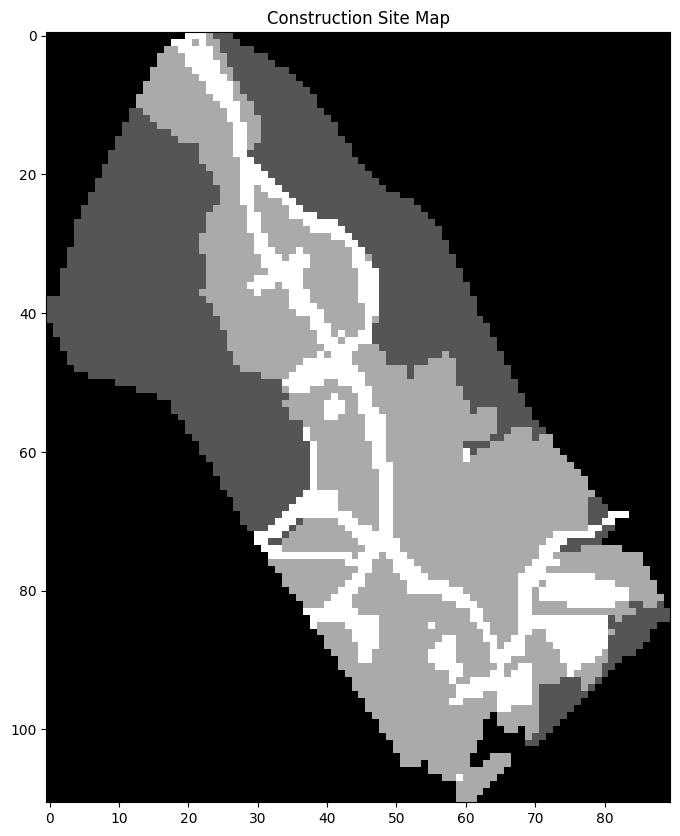

Saved figure: __RESULTS__/_plots/06-02-03-43/construction_map.png


In [4]:
vis.showMap(map_data=map, title="Construction Site Map", cmap='gray', filename="construction_map")

Installable map
<br><sub> A binary grid mask that defines physically feasible sensor deployment locations on the site. </sub>

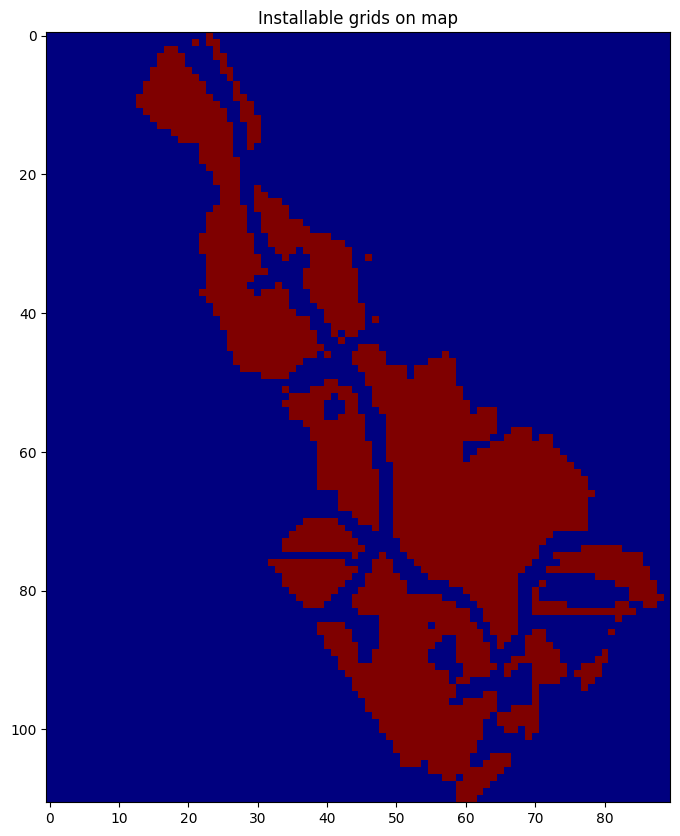

Saved figure: __RESULTS__/_plots/06-02-03-43/installable_map.png


In [5]:
installable_layer = layer_map(map, keep_values=[2])
vis.showMap(map_data=installable_layer, title="Installable grids on map", cmap='jet', filename="installable_map")

Uninstallable map
<br><sub>Regions excluded from sensor deployment due to safety, accessibility, or operational constraints <br>(e.g., equipment routes, waterlogged areas, vegetation, and offices).</sub>

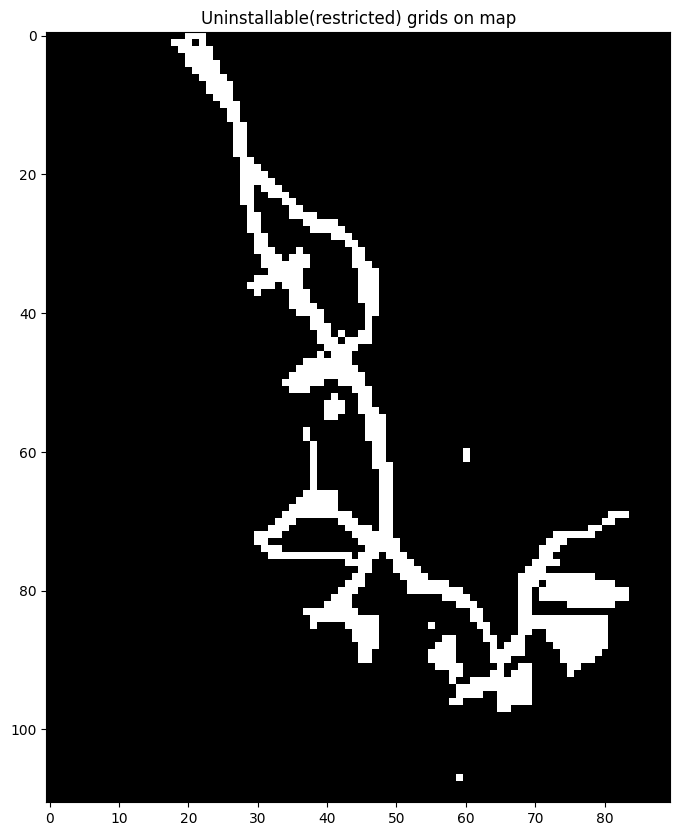

Saved figure: __RESULTS__/_plots/06-02-03-43/restricted__map.png


In [6]:
road_layer = layer_map(map, keep_values=[3])
vis.showMap(map_data=road_layer, title="Uninstallable(restricted) grids on map", cmap="gray", filename="restricted__map")

Jobsite area
<br><sub>The coverage target area for sensor deployment, defined as the union of installable and non-installable regions.</sub>

========== MAP CHECK ==========
Map shape (H,W): 111 x 90
Grid size: 5.0m x 5.0m  |  Cell area: 25.0 m^2
--------------------------------
Total cells: 9,990
Total area : 249,750.00 m^2  |  24.9750 ha  |  0.249750 km^2
--------------------------------
Target value      : 1
Target area       : 72,550.00 m^2  |  7.2550 ha  |  0.072550 km^2
Target cells      : 2,902  (29.05%)
--------------------------------
Value counts (entire map):
  - value 0: 7,088 (70.95%)
  - value 1: 2,902 (29.05%)


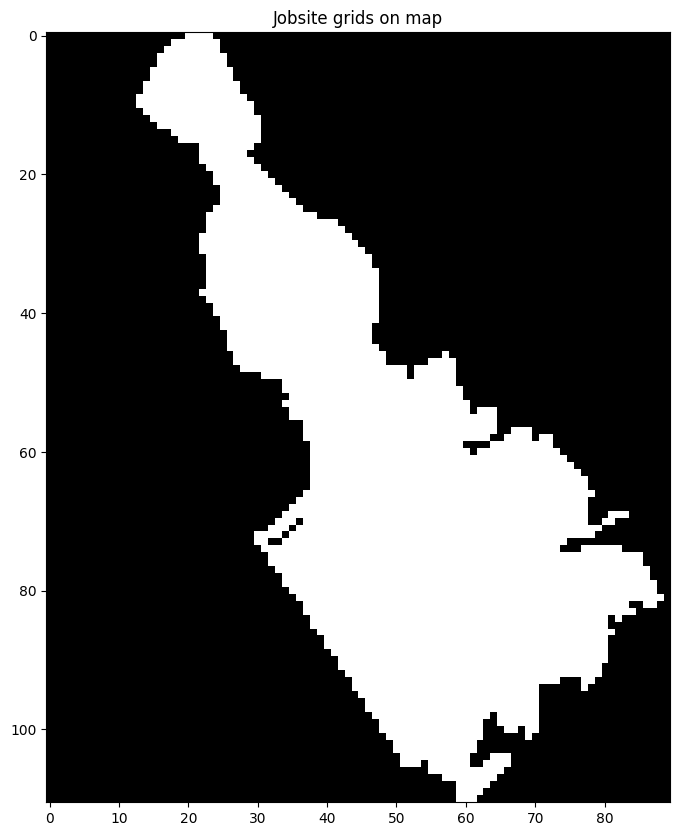

Saved figure: __RESULTS__/_plots/06-02-03-43/map_check.png


In [7]:
jobsite_layer = layer_map(map, keep_values=[2,3])
vis.map_check(map_data=jobsite_layer,title="Jobsite grids on map", return_stats=False, cmap="gray")

### Systematic sensor deployment

In [8]:
#Set sensor coverage radius
COVERAGE = 45

Outermost corner location candidate extraction
<br><sub> Detection of outermost feasible sensor placement candidates within installable regions, since environmental sensing modules must be deployed at the site boundaries to capture extreme conditions. </sub>

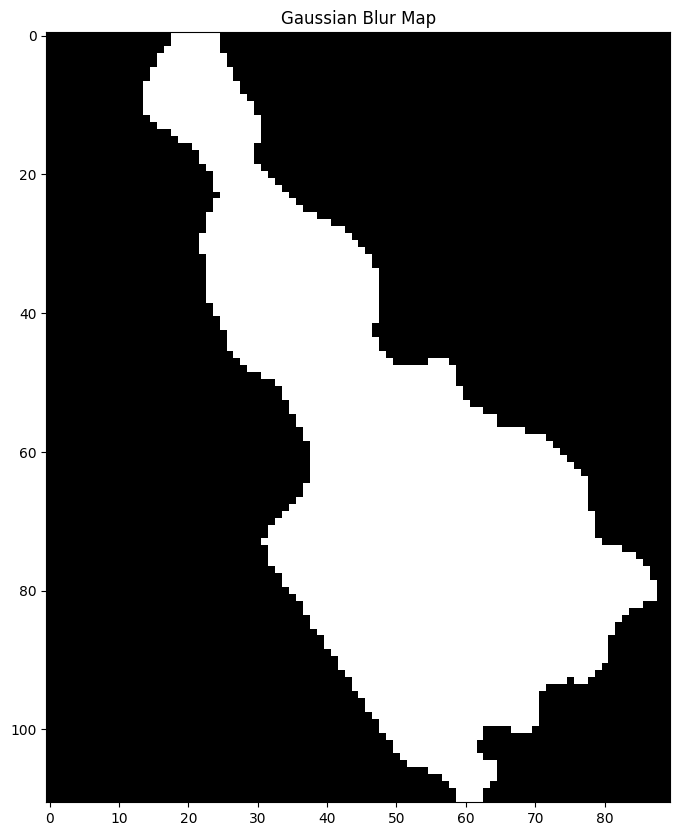

Saved figure: __RESULTS__/_plots/06-02-03-43/gaussian_blur_map.png


In [9]:
from OuterDeployment.HarrisCorner import HarrisCorner

corner_instance = HarrisCorner(jobsite_layer)

blur_map = corner_instance.gaussianBlur(grid=jobsite_layer)
vis.showMap(map_data=blur_map, title="Gaussian Blur Map", cmap='gray', filename="gaussian_blur_map")

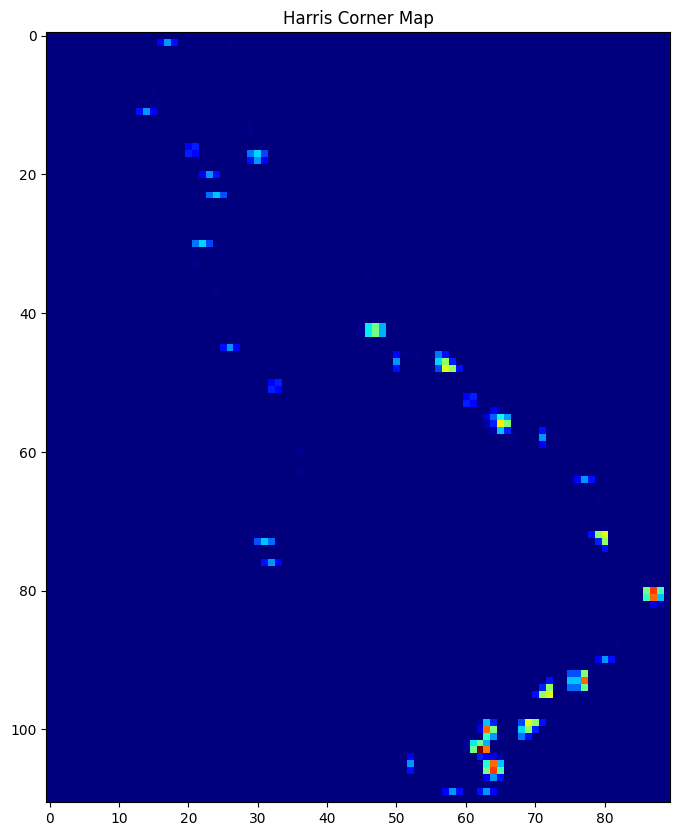

Saved figure: __RESULTS__/_plots/06-02-03-43/harris_corner_map.png


In [10]:
corner_heatmap = corner_instance.harrisCorner(
                                                grid=blur_map,
                                                block_size=3,
                                                ksize=3,
                                                k=0.05
                                                )
vis.showMap(map_data=corner_heatmap, title="Harris Corner Map", cmap="jet", filename="harris_corner_map")

Total outermost sensors : 8


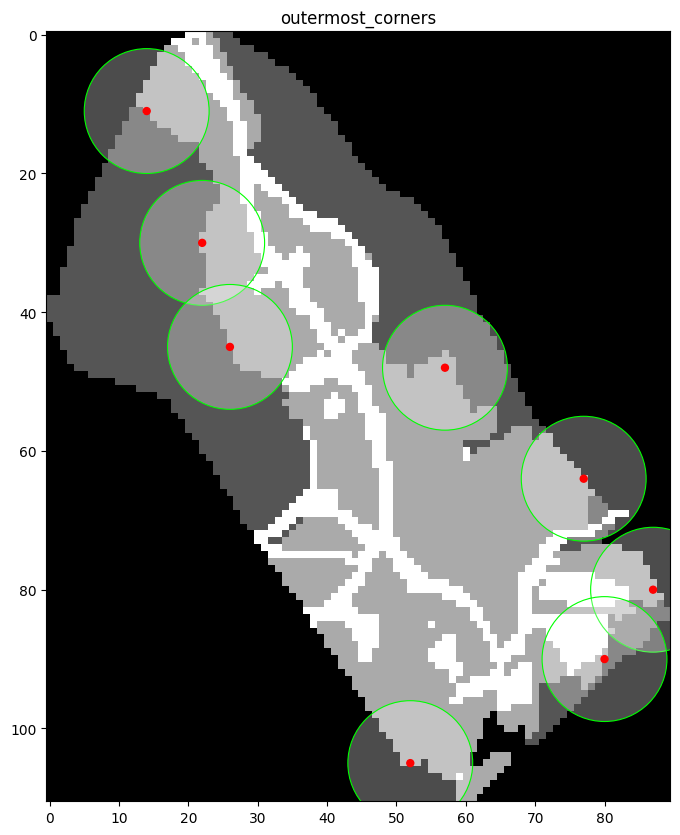

Saved figure: __RESULTS__/_plots/06-02-03-43/corner_sensors.png


In [11]:
corners = corner_instance.LMX(harris_map=corner_heatmap, installable_map=installable_layer, min_dist=9)

print("Total outermost sensors :",len(corners))
vis.showMap_circle(
    map_data=map, 
    sensor_positions=corners, 
    title="outermost_corners",
    cmap="gray",
    filename="corner_sensors"
    )

Outmost corner points: 8


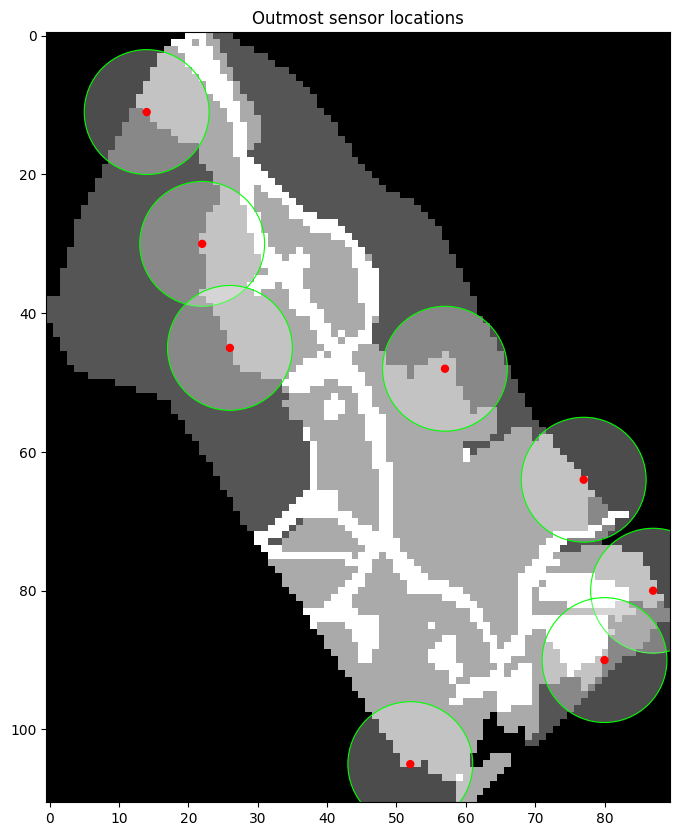

Saved figure: __RESULTS__/_plots/06-02-03-43/corner_sensors.png


In [12]:
corner_layer = HarrisCorner(jobsite_layer)
corner_candidate = corner_layer.run(
    grid=jobsite_layer,                
    installable_layer=installable_layer, 
    blockSize=3,
    ksize=3,
    k=0.05,
    dilate_size=5,
    min_dist=9,
)

print("Outmost corner points:", len(corner_candidate))
vis.showMap_circle(map_data=map, sensor_positions=corner_candidate, title="Outmost sensor locations",radius=COVERAGE, cmap='gray', filename="corner_sensors")

Inner-Deployment Strategy: Particle Swarm Optimization (PSO)
<br><sub>Particle Swarm Optimization is used to optimize the placement of inner sensors while preserving the same map preprocessing and outermost sensor extraction flow.</sub>

In [13]:
from InnerDeployment.PSO.main import SensorPSO

pso = SensorPSO(
                installable_map=installable_layer,
                jobsite_map=jobsite_layer,
                coverage=COVERAGE,
                generations=100,
                corner_positions=corner_candidate,
                swarm_size=100,
                min_sensors=0,
                max_sensors=140,
                initial_min_sensors=40,
                initial_max_sensors=140,
            )

optimized_result = pso.run(
                    early_stop=True,
                    early_stop_coverage=90.0,
                    early_stop_patience=10,
                    return_best_only=True
                )

[PSO 001/100] sensors: (min=40, avg=91.5, max=140) / coverage: 100.00% (target=90.00%) / best_inner=40 (corner=8) / time=0.446s
[PSO 002/100] sensors: (min=40, avg=91.3, max=140) / coverage: 100.00% (target=90.00%) / best_inner=40 (corner=8) / time=0.448s
[PSO 003/100] sensors: (min=39, avg=91.2, max=140) / coverage: 100.00% (target=90.00%) / best_inner=39 (corner=8) / time=0.443s
[PSO 004/100] sensors: (min=39, avg=91.0, max=140) / coverage: 100.00% (target=90.00%) / best_inner=39 (corner=8) / time=0.454s
[PSO 005/100] sensors: (min=39, avg=90.7, max=140) / coverage: 100.00% (target=90.00%) / best_inner=39 (corner=8) / time=0.449s
[PSO 006/100] sensors: (min=38, avg=90.6, max=140) / coverage: 100.00% (target=90.00%) / best_inner=38 (corner=8) / time=0.448s
[PSO 007/100] sensors: (min=37, avg=90.4, max=140) / coverage: 100.00% (target=90.00%) / best_inner=37 (corner=8) / time=0.445s
[PSO 008/100] sensors: (min=37, avg=90.2, max=140) / coverage: 100.00% (target=90.00%) / best_inner=37 (

In [14]:
print("[FINALIZE OUTPUT] pso.best_solution =", pso.best_solution)
print("[FINALIZE OUTPUT] len(pso.best_solution) =", len(pso.best_solution))
print("[FINALIZE OUTPUT] pso.corner_points =", pso.corner_points)
print("[FINALIZE OUTPUT] len(pso.corner_points) =", len(pso.corner_points))

[FINALIZE OUTPUT] pso.best_solution = [(47, 97), (38, 29), (67, 83), (50, 65), (32, 76), (30, 12), (51, 82), (60, 110), (47, 52), (17, 2), (63, 92), (24, 21), (44, 36), (41, 89), (71, 73), (35, 55)]
[FINALIZE OUTPUT] len(pso.best_solution) = 16
[FINALIZE OUTPUT] pso.corner_points = [(14, 11), (22, 30), (26, 45), (57, 48), (77, 64), (87, 80), (80, 90), (52, 105)]
[FINALIZE OUTPUT] len(pso.corner_points) = 8


Total number of Sensor : 24


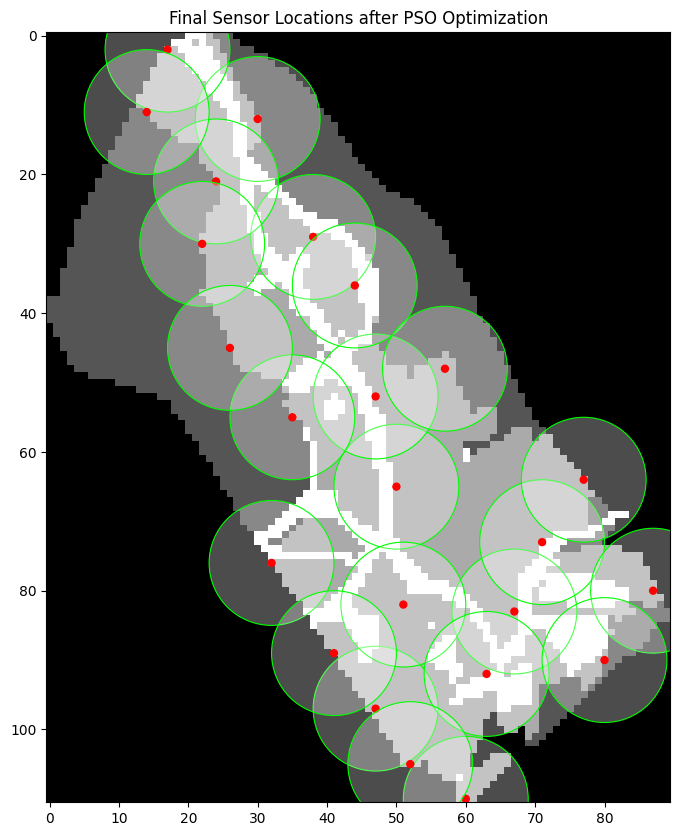

Saved figure: __RESULTS__/_plots/06-02-03-43/final_sensors_pso.png


In [15]:
final_result = optimized_result + corner_candidate
print("Total number of Sensor :", len(final_result))
vis.showMap_circle(
    map_data=map, 
    sensor_positions=final_result,
    title="Final Sensor Locations after PSO Optimization",
    radius=COVERAGE,
    cmap='gray',
    filename="final_sensors_pso"
    )